# Taller Práctico 3 — Python para Ciencia de Datos
### Maestría en Ciencia de Datos y Machine Learning (mención IA) — UIDE

**Integrantes** 
- Kevin Apolo  
- Sthefanny Chamorro  
- José Luis Criollo

**Repositorio:** `github.com/jose264/TallerSemana03`

---

Consolidación de las entregas académicas de dos campus y su cruce con el catálogo maestro
de estudiantes, mediante un flujo reproducible, automatizado y auditable.




---
## Estructuración del proyecto

Se define la estructura del proyecto y las rutas de trabajo para mantener el proceso ordenado y reproducible.

### Librerías y entorno

Se cargan las librerías necesarias y se muestran sus versiones para dejar constancia del entorno.

In [1]:
import sys
from pathlib import Path
from datetime import datetime

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

print(f"Python     : {sys.version.split()[0]}")
print(f"pandas     : {pd.__version__}")
print(f"numpy      : {np.__version__}")
print(f"matplotlib : {plt.matplotlib.__version__}")

Python     : 3.11.0
pandas     : 2.3.3
numpy      : 2.3.5
matplotlib : 3.10.0


### Parámetros y rutas del proyecto

Las rutas se localizan desde la raíz del proyecto y las carpetas de salida se crean si no existen.

In [2]:
# --- Localización de la raíz del proyecto ---
# Rutas relativas:
# hacia arriba, de modo que funciona desde notebooks/ o desde la raiz.
def localizar_raiz(marcador="datos"):
    actual = Path.cwd()
    for candidata in [actual, *actual.parents]:
        if (candidata / marcador).is_dir():
            return candidata
    return actual


raiz = localizar_raiz()

originales      = raiz / "datos" / "originales"
procesados      = raiz / "datos" / "procesados"
scripts         = raiz / "scripts"
reportes        = raiz / "reportes"
visualizaciones = raiz / "visualizaciones"

# Creacion de las capas de salida si no existen
for carpeta in [procesados, reportes, visualizaciones]:
    carpeta.mkdir(parents=True, exist_ok=True)

print(f"Raíz del proyecto: {raiz.name}")
for carpeta in [originales, procesados, scripts, reportes, visualizaciones]:
    print(f"  {carpeta.relative_to(raiz)}")

Raíz del proyecto: TallerSemana03
  datos\originales
  datos\procesados
  scripts
  reportes
  visualizaciones


#### Parámetros del proceso

Se centralizan fechas, claves y archivos para evitar valores repetidos en el flujo.

In [3]:
# --- Parámetros del proceso ---
sello = datetime.now().strftime("%Y%m%d")
fecha_proceso = datetime.now().strftime("%Y-%m-%d")

clave_estudiante = "id_estudiante"
clave_entrega    = "id_entrega"

archivos_entregas = {
    "Matriz":    originales / "entregas_campus_matriz.csv",
    "Extensión": originales / "entregas_campus_extension.csv",
}
archivo_maestro = originales / "estudiantes_master.xlsx"

print(f"Fecha de proceso: {fecha_proceso}")

Fecha de proceso: 2026-08-18


## Lectura parametrizada

Las fuentes se leen mediante funciones reutilizables para evitar repetir lógica y mantener un criterio uniforme.

### Funciones reutilizables

Las funciones de lectura se importan desde `scripts/lectura.py` para mantener la lógica centralizada.

In [4]:
sys.path.append(str(scripts))

from lectura import (
    leer_entregas_csv,
    leer_catalogo_maestro,
    normalizar_json_anidado,
)

print("Funciones de lectura importadas desde scripts/lectura.py")

Funciones de lectura importadas desde scripts/lectura.py


In [5]:
# --- Ciclo de lectura parametrizada ---
entregas_por_campus = {}
bitacora_lectura = []

for campus, ruta in archivos_entregas.items():
    df = leer_entregas_csv(ruta)
    entregas_por_campus[campus] = df

    bitacora_lectura.append({
        "fuente": ruta.name,
        "campus": campus,
        "origen_lectura": "csv",
        "registros": len(df),
        "columnas": df.shape[1],
    })
    print(f"{campus:12s} {len(df):4d} registros")

entregas_por_campus["Matriz"].head(3)

Matriz        150 registros
Extensión     150 registros


,id_entrega,id_estudiante,fecha_subida,materia,tipo_proyecto,puntaje_obtenido,estado_entrega
0,PRJ-1001,E001,2026-08-01,Sistemas de Bases de Datos,Modelado ER,95.5,Aprobado
1,PRJ-1002,E002,2026-08-02,Desarrollo de Software,Prototipo,88.0,Aprobado
2,PRJ-1003,E003,2026-08-03,DataOps,Pipeline,92.0,Aprobado


#### Lectura del catálogo maestro

El archivo tiene extensión `.xlsx`, pero su contenido corresponde a texto CSV. Por eso se utiliza una lectura defensiva que comprueba el formato real.

In [6]:
# --- Evidencia de lectura del catálogo ---
try:
    pd.read_excel(archivo_maestro)
    print("read_excel() funcionó")
except Exception as e:
    print(f"read_excel() falla -> {type(e).__name__}")
    print(f"  {str(e)[:88]}")

read_excel() falla -> ValueError
  Excel file format cannot be determined, you must specify an engine manually.


In [7]:
# --- Lectura defensiva del catálogo ---
df_maestro = leer_catalogo_maestro(archivo_maestro)

bitacora_lectura.append({
    "fuente": archivo_maestro.name,
    "campus": "Catálogo",
    "origen_lectura": df_maestro.attrs["origen_lectura"],
    "registros": len(df_maestro),
    "columnas": df_maestro.shape[1],
})
df_bitacora_lectura = pd.DataFrame(bitacora_lectura)

print(f"Maestro: {len(df_maestro)} registros")
print(f"Leído como: {df_maestro.attrs['origen_lectura']}")
print(f"\nTipos de dato:")
print(df_maestro.dtypes)
df_maestro.head(3)

Maestro: 60 registros
Leído como: csv_disfrazado_de_excel

Tipos de dato:
id_estudiante       string[python]
nombre_completo     string[python]
fecha_nacimiento    datetime64[ns]
carrera             string[python]
campus_origen       string[python]
tipo_beca           string[python]
estado_academico    string[python]
dtype: object


,id_estudiante,nombre_completo,fecha_nacimiento,carrera,campus_origen,tipo_beca,estado_academico
0,E001,Mateo Alvarado,1998-05-12,Ingeniería de Software,Matriz,Completa,Activo
1,E002,Camila Sánchez,2000-02-20,Ingeniería de Software,Matriz,Parcial,Activo
2,E003,Santiago Ríos,1999-03-10,Ciencias de Datos,Matriz,Ninguna,Activo


In [8]:
# --- Resumen de lectura ---
df_bitacora_lectura

,fuente,campus,origen_lectura,registros,columnas
0,entregas_campus_matriz.csv,Matriz,csv,150,7
1,entregas_campus_extension.csv,Extensión,csv,150,7
2,estudiantes_master.xlsx,Catálogo,csv_disfrazado_de_excel,60,7


---

## Validaciones e integración

Primero se comprueba la estructura y las claves; después se combinan las fuentes.

### Funciones de validación e integración

Las validaciones y operaciones de combinación se reutilizan desde `scripts/funciones.py`.

In [9]:
from funciones import (
    validar_columnas,
    validar_clave_unica,
    controlar_duplicados,
    consolidar_campus,
    cruzar_maestro,
    generar_reporte_calidad,
)

print("Funciones de validación e integración importadas desde scripts/funciones.py")

Funciones de validación e integración importadas desde scripts/funciones.py


### Validaciones estructurales

Se verifica que cada fuente tenga las columnas necesarias antes de combinarla.

In [10]:
# --- Validación de columnas esperadas ---
columnas_entregas = [
    "id_entrega", "id_estudiante", "fecha_subida", "materia",
    "tipo_proyecto", "puntaje_obtenido", "estado_entrega",
]
columnas_maestro = [
    "id_estudiante", "nombre_completo", "fecha_nacimiento", "carrera",
    "campus_origen", "tipo_beca", "estado_academico",
]

for campus, df in entregas_por_campus.items():
    validar_columnas(df, columnas_entregas, f"Entregas {campus}")
    print(f"  Entregas {campus:12s} estructura OK")

validar_columnas(df_maestro, columnas_maestro, "Catálogo maestro")
print(f"  Catálogo maestro          estructura OK")

  Entregas Matriz       estructura OK
  Entregas Extensión    estructura OK
  Catálogo maestro          estructura OK


In [11]:
# --- Control de duplicados por fuente ---
controles = []

for campus, df in entregas_por_campus.items():
    df_limpio, control = controlar_duplicados(df, clave_entrega, f"Entregas {campus}")
    entregas_por_campus[campus] = df_limpio
    controles.append(control)

df_maestro, control = controlar_duplicados(df_maestro, clave_estudiante, "Catálogo")
controles.append(control)

df_controles = pd.DataFrame(controles)
df_controles

,fuente,duplicados_exactos,duplicados_por_clave
0,Entregas Matriz,0,0
1,Entregas Extensión,0,0
2,Catálogo,0,0


In [12]:
# --- Validación de clave única ---
validar_clave_unica(df_maestro, clave_estudiante, "Catálogo maestro")
print(f"Clave '{clave_estudiante}' única: "
      f"{df_maestro[clave_estudiante].nunique()} de {len(df_maestro)} registros")

Clave 'id_estudiante' única: 60 de 60 registros


## Estrategia de combinación

Los dos campus se apilan y luego se relacionan con el catálogo maestro usando la clave del estudiante.

### Preparación de la integración

Se comprueba el efecto de reiniciar los índices antes de consolidar los campus.

In [13]:
# --- Evidencia del efecto de ignore_index ---
sin_parametro = pd.concat(list(entregas_por_campus.values()))
con_parametro = pd.concat(list(entregas_por_campus.values()), ignore_index=True)

print(f"Sin ignore_index -> índices duplicados: {sin_parametro.index.duplicated().sum()}")
print(f"Con ignore_index -> índices duplicados: {con_parametro.index.duplicated().sum()}")

Sin ignore_index -> índices duplicados: 150
Con ignore_index -> índices duplicados: 0


In [14]:
# --- Consolidación de ambos campus ---
df_entregas = consolidar_campus(
    list(entregas_por_campus.values()),
    columna_origen="campus_entrega",
    etiquetas=list(entregas_por_campus.keys()),
)

print(f"Entregas consolidadas: {len(df_entregas)}")
print(f"\nDistribución por campus:")
print(df_entregas["campus_entrega"].value_counts())

validar_clave_unica(df_entregas, clave_entrega, "Entregas consolidadas")
print(f"\nClave '{clave_entrega}' única tras el apilado: OK")

Entregas consolidadas: 300

Distribución por campus:
campus_entrega
Matriz       150
Extensión    150
Name: count, dtype: int64

Clave 'id_entrega' única tras el apilado: OK


#### Integración relacional: `merge`

El cruce se realiza con cardinalidad `many_to_one` para evitar combinaciones incorrectas.

In [15]:
# --- Cruce validado ---
df_consolidado = cruzar_maestro(
    df_entregas,
    df_maestro,
    clave=clave_estudiante,
    cardinalidad="many_to_one",
)

print(f"Registros: {len(df_entregas)} -> {len(df_consolidado)}")
print(f"\nOrigen de cada fila:")
print(df_consolidado["_origen"].value_counts())

Registros: 300 -> 300

Origen de cada fila:
_origen
both          295
left_only       5
right_only      0
Name: count, dtype: int64


#### Claves sin correspondencia

Se identifican las entregas cuyo estudiante no aparece en el catálogo maestro, sin eliminar esos registros.

In [16]:
# --- Identificación de entregas huérfanas ---
huerfanas = df_consolidado["_origen"] == "left_only"
df_huerfanas = df_consolidado[huerfanas]

print(f"Entregas sin estudiante en el maestro: {len(df_huerfanas)}")
print(f"Identificadores afectados: "
      f"{sorted(df_huerfanas[clave_estudiante].unique())}")

df_huerfanas[[clave_entrega, clave_estudiante, "materia",
              "estado_entrega", "campus_entrega"]]

Entregas sin estudiante en el maestro: 5
Identificadores afectados: ['E555', 'E666', 'E777', 'E888', 'E999']


,id_entrega,id_estudiante,materia,estado_entrega,campus_entrega
157,PRJ-2008,E999,Desarrollo de Software,Aprobado,Extensión
167,PRJ-2018,E888,DataOps,Revisión,Extensión
181,PRJ-2032,E777,DataOps,Pendiente,Extensión
230,PRJ-2081,E666,DataOps,Aprobado,Extensión
268,PRJ-2119,E555,Sistemas de Bases de Datos,Aprobado,Extensión


Los identificadores siguen un patrón que sugiere registros de prueba. Aun así **no se
eliminan**: corresponden a entregas efectivamente registradas y descartarlas alteraría el
conteo del reporte. Se conservan marcadas para que el área responsable resuelva su origen.

In [17]:
# --- Indicador de correspondencia ---
df_consolidado["estudiante_identificado"] = df_consolidado["_origen"] == "both"
df_consolidado = df_consolidado.drop(columns="_origen")

print(f"Identificados   : {df_consolidado['estudiante_identificado'].sum()}")
print(f"Sin identificar : {(~df_consolidado['estudiante_identificado']).sum()}")

Identificados   : 295
Sin identificar : 5


#### Nulos con causa identificable

Se comprueba si los puntajes nulos corresponden a entregas que están pendientes.

In [18]:
# --- Relación entre nulos y estado ---
tabla_patron = pd.crosstab(
    df_consolidado["estado_entrega"],
    df_consolidado["puntaje_obtenido"].isna(),
    rownames=["estado_entrega"],
    colnames=["puntaje_nulo"],
)
print(tabla_patron)

nulos_puntaje = int(df_consolidado["puntaje_obtenido"].isna().sum())
pendientes = int((df_consolidado["estado_entrega"] == "Pendiente").sum())

print(f"\nPuntajes nulos    : {nulos_puntaje}")
print(f"Entregas Pendiente: {pendientes}")
print(f"Coincidencia total: {nulos_puntaje == pendientes}")

puntaje_nulo    False  True 
estado_entrega              
Aprobado          276      0
Pendiente           0      9
Revisión           15      0

Puntajes nulos    : 9
Entregas Pendiente: 9
Coincidencia total: True


Los puntajes nulos coinciden exactamente con las entregas en estado `Pendiente`. No son
datos perdidos, sino entregas que aún no han sido calificadas: la ausencia es
estructuralmente correcta.

En consecuencia **no se imputan ni se eliminan**. Se excluyen del cálculo de promedios,
pero se conservan en el conteo de entregas.

---

##  Automatización e indicadores de calidad

Se generan variables derivadas, resúmenes, visualizaciones y reportes de control.

#### Clasificación de valores nulos

Se separan los nulos críticos de los que tienen una causa esperada.

In [19]:
# --- Clasificación de nulos ---
columnas_criticas = [clave_entrega, clave_estudiante, "fecha_subida"]

nulos_criticos = int(df_consolidado[columnas_criticas].isna().sum().sum())
nulos_esperados = nulos_puntaje

df_consolidado["puntaje_pendiente"] = df_consolidado["puntaje_obtenido"].isna()

print(f"Nulos CRÍTICOS  (clave o fecha)      : {nulos_criticos}")
print(f"Nulos ESPERADOS (entregas pendientes): {nulos_esperados}")
print("\nUn nulo es crítico si impide procesar el registro;")
print("es esperado si su ausencia tiene una causa identificable.")

Nulos CRÍTICOS  (clave o fecha)      : 0
Nulos ESPERADOS (entregas pendientes): 9

Un nulo es crítico si impide procesar el registro;
es esperado si su ausencia tiene una causa identificable.


#### Variables derivadas y agregación

Se crean variables útiles para el análisis y se preparan los resúmenes.

In [20]:
# --- Variables derivadas ---
df_consolidado["anio_entrega"] = df_consolidado["fecha_subida"].dt.year
df_consolidado["mes_entrega"] = df_consolidado["fecha_subida"].dt.month
df_consolidado["aprobado"] = df_consolidado["estado_entrega"] == "Aprobado"
df_consolidado["fecha_procesamiento"] = fecha_proceso

print(f"Dimensiones finales: {df_consolidado.shape}")
df_consolidado.head(3)

Dimensiones finales: (300, 20)


,id_entrega,id_estudiante,fecha_subida,materia,tipo_proyecto,puntaje_obtenido,estado_entrega,campus_entrega,nombre_completo,fecha_nacimiento,carrera,campus_origen,tipo_beca,estado_academico,estudiante_identificado,puntaje_pendiente,anio_entrega,mes_entrega,aprobado,fecha_procesamiento
0,PRJ-1001,E001,2026-08-01,Sistemas de Bases de Datos,Modelado ER,95.5,Aprobado,Matriz,Mateo Alvarado,1998-05-12,Ingeniería de Software,Matriz,Completa,Activo,True,False,2026,8,True,2026-08-18
1,PRJ-1002,E002,2026-08-02,Desarrollo de Software,Prototipo,88.0,Aprobado,Matriz,Camila Sánchez,2000-02-20,Ingeniería de Software,Matriz,Parcial,Activo,True,False,2026,8,True,2026-08-18
2,PRJ-1003,E003,2026-08-03,DataOps,Pipeline,92.0,Aprobado,Matriz,Santiago Ríos,1999-03-10,Ciencias de Datos,Matriz,Ninguna,Activo,True,False,2026,8,True,2026-08-18


In [21]:
# --- Agregación por campus ---
resumen_campus = (
    df_consolidado.groupby("campus_entrega")
    .agg(
        entregas=(clave_entrega, "count"),
        estudiantes=(clave_estudiante, "nunique"),
        puntaje_promedio=("puntaje_obtenido", "mean"),
        desviacion=("puntaje_obtenido", "std"),
        pendientes=("puntaje_pendiente", "sum"),
    )
    .round(2)
    .reset_index()
)
resumen_campus

,campus_entrega,entregas,estudiantes,puntaje_promedio,desviacion,pendientes
0,Extensión,150,30,90.70,6.30,3
1,Matriz,150,34,89.99,6.95,6


In [22]:
# --- Agregación por materia ---
resumen_materia = (
    df_consolidado.groupby("materia")
    .agg(
        entregas=(clave_entrega, "count"),
        puntaje_promedio=("puntaje_obtenido", "mean"),
        tasa_aprobacion=("aprobado", "mean"),
    )
    .round(2)
    .sort_values("puntaje_promedio", ascending=False)
    .reset_index()
)
resumen_materia

,materia,entregas,puntaje_promedio,tasa_aprobacion
0,Desarrollo de Software,104,90.75,0.95
1,DataOps,96,90.53,0.92
2,Sistemas de Bases de Datos,100,89.73,0.89


### Visualización

Se generan gráficos simples para revisar la distribución de las entregas y sus estados.

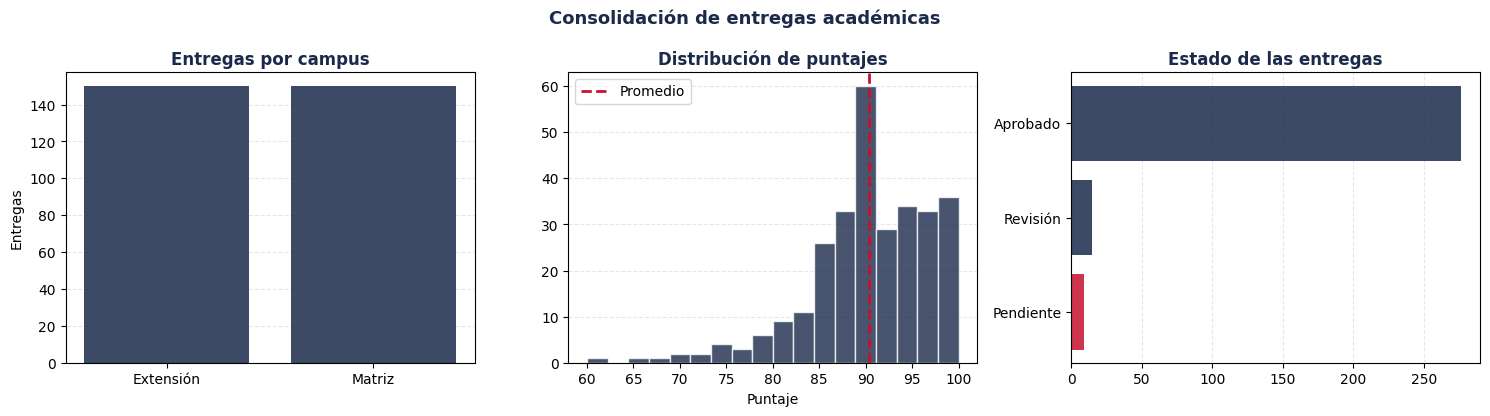

Gráfico guardado en visualizaciones\resumen_entregas_20260818.png


In [23]:
navy = "#1B2A4A"
rojo = "#C8102E"

fig, axes = plt.subplots(1, 3, figsize=(15, 4.2))
fig.suptitle("Consolidación de entregas académicas", fontsize=13,
             fontweight="bold", color=navy)

ax = axes[0]
ax.bar(resumen_campus["campus_entrega"], resumen_campus["entregas"],
       color=navy, alpha=0.85)
ax.set_title("Entregas por campus", fontweight="bold", color=navy)
ax.set_ylabel("Entregas")
ax.grid(alpha=0.3, axis="y", linestyle="--")
ax.set_axisbelow(True)

ax = axes[1]
ax.hist(df_consolidado["puntaje_obtenido"].dropna(), bins=18,
        color=navy, alpha=0.8, edgecolor="white")
ax.axvline(df_consolidado["puntaje_obtenido"].mean(), color=rojo,
           linestyle="--", linewidth=2, label="Promedio")
ax.set_title("Distribución de puntajes", fontweight="bold", color=navy)
ax.set_xlabel("Puntaje")
ax.legend()
ax.grid(alpha=0.3, axis="y", linestyle="--")
ax.set_axisbelow(True)

ax = axes[2]
estados = df_consolidado["estado_entrega"].value_counts()
colores = [navy if e != "Pendiente" else rojo for e in estados.index]
ax.barh(estados.index, estados.values, color=colores, alpha=0.85)
ax.set_title("Estado de las entregas", fontweight="bold", color=navy)
ax.invert_yaxis()
ax.grid(alpha=0.3, axis="x", linestyle="--")
ax.set_axisbelow(True)

plt.tight_layout()

ruta_grafico = visualizaciones / f"resumen_entregas_{sello}.png"
plt.savefig(ruta_grafico, dpi=110, bbox_inches="tight")
plt.show()

print(f"Gráfico guardado en {ruta_grafico.relative_to(raiz)}")

## Indicadores de calidad del proceso

Se exportan los resultados y se resumen los principales indicadores para comprobar el procesamiento.

### Exportación

Se guardan el dataset consolidado y los resúmenes en la capa de datos procesados.

In [24]:
# --- Exportación a datos procesados ---
ruta_dataset = procesados / f"entregas_consolidadas_{sello}.csv"
df_consolidado.to_csv(ruta_dataset, index=False, encoding="utf-8-sig")

ruta_resumen_campus = procesados / f"resumen_campus_{sello}.csv"
ruta_resumen_materia = procesados / f"resumen_materia_{sello}.csv"
resumen_campus.to_csv(ruta_resumen_campus, index=False, encoding="utf-8-sig")
resumen_materia.to_csv(ruta_resumen_materia, index=False, encoding="utf-8-sig")

# Verificacion de la exportacion
df_verificacion = pd.read_csv(ruta_dataset, dtype={clave_estudiante: str})
if len(df_verificacion) != len(df_consolidado):
    raise ValueError("El archivo exportado no coincide con el dataset.")

print(f"Dataset  : {ruta_dataset.name}  ({ruta_dataset.stat().st_size/1024:.1f} KB)")
print(f"Resúmenes: {ruta_resumen_campus.name}, {ruta_resumen_materia.name}")
print(f"Columna de índice residual: {'Unnamed: 0' in df_verificacion.columns}")

Dataset  : entregas_consolidadas_20260818.csv  (54.1 KB)
Resúmenes: resumen_campus_20260818.csv, resumen_materia_20260818.csv
Columna de índice residual: False


#### Indicadores de calidad

Se calculan métricas básicas de lectura, descarte, correspondencia y nulos.

In [25]:
# --- Indicadores de calidad ---
registros_leidos = sum(b["registros"] for b in bitacora_lectura)
registros_descartados = sum(c["duplicados_exactos"] for c in controles)

archivos_generados = [
    ruta_dataset.name,
    ruta_resumen_campus.name,
    ruta_resumen_materia.name,
    ruta_grafico.name,
]

indicadores = {
    "archivos_procesados": len(bitacora_lectura),
    "registros_leidos": registros_leidos,
    "registros_descartados": registros_descartados,
    "claves_sin_correspondencia": int(huerfanas.sum()),
    "nulos_criticos": nulos_criticos,
    "nulos_esperados": nulos_esperados,
    "dimensiones_salida": f"{df_consolidado.shape[0]} x {df_consolidado.shape[1]}",
    "archivos_generados": len(archivos_generados) + 2,   # + reporte y bitácora
    "fecha_procesamiento": fecha_proceso,
}

df_indicadores = generar_reporte_calidad(indicadores)

print("INDICADORES DE CALIDAD DEL PROCESO")
print("=" * 52)
for clave, valor in indicadores.items():
    print(f"  {clave:28s}: {valor}")

INDICADORES DE CALIDAD DEL PROCESO
  archivos_procesados         : 3
  registros_leidos            : 360
  registros_descartados       : 0
  claves_sin_correspondencia  : 5
  nulos_criticos              : 0
  nulos_esperados             : 9
  dimensiones_salida          : 300 x 20
  archivos_generados          : 6
  fecha_procesamiento         : 2026-08-18


#### Reportes de control

Los indicadores y la bitácora de lectura se exportan para dejar trazabilidad.

In [26]:
# --- Exportación de reportes ---
ruta_reporte = reportes / f"indicadores_calidad_{sello}.csv"
ruta_bitacora = reportes / f"bitacora_lectura_{sello}.csv"

df_indicadores.to_csv(ruta_reporte, index=False, encoding="utf-8-sig")
df_bitacora_lectura.to_csv(ruta_bitacora, index=False, encoding="utf-8-sig")

print(f"Reporte de indicadores: {ruta_reporte.relative_to(raiz)}")
print(f"Bitácora de lectura   : {ruta_bitacora.relative_to(raiz)}")
df_indicadores

Reporte de indicadores: reportes\indicadores_calidad_20260818.csv
Bitácora de lectura   : reportes\bitacora_lectura_20260818.csv


,indicador,valor
0,archivos_procesados,3
1,registros_leidos,360
2,registros_descartados,0
3,claves_sin_correspondencia,5
4,nulos_criticos,0
5,nulos_esperados,9
6,dimensiones_salida,300 x 20
7,archivos_generados,6
8,fecha_procesamiento,2026-08-18


## Reproducibilidad técnica

El flujo documenta rutas, funciones, dependencias, trazabilidad y salidas para facilitar su ejecución nuevamente.

In [27]:
print("=" * 55)
print("RESUMEN DEL PROCESAMIENTO")
print("=" * 55)
print(f"Archivos procesados        : {indicadores['archivos_procesados']}")
print(f"Registros leídos           : {indicadores['registros_leidos']}")
print(f"Entregas consolidadas      : {len(df_consolidado)}")
print(f"Claves sin correspondencia : {indicadores['claves_sin_correspondencia']}")
print(f"Nulos críticos             : {indicadores['nulos_criticos']}")
print(f"Nulos esperados            : {indicadores['nulos_esperados']}")
print()
print("Archivos generados:")
for carpeta in [procesados, reportes, visualizaciones]:
    for archivo in sorted(carpeta.glob(f"*{sello}*")):
        print(f"  {archivo.relative_to(raiz)}")
print()
print("Estado: PROCESAMIENTO EXITOSO")

RESUMEN DEL PROCESAMIENTO
Archivos procesados        : 3
Registros leídos           : 360
Entregas consolidadas      : 300
Claves sin correspondencia : 5
Nulos críticos             : 0
Nulos esperados            : 9

Archivos generados:
  datos\procesados\entregas_consolidadas_20260818.csv
  datos\procesados\resumen_campus_20260818.csv
  datos\procesados\resumen_materia_20260818.csv
  reportes\bitacora_lectura_20260818.csv
  reportes\indicadores_calidad_20260818.csv
  visualizaciones\resumen_entregas_20260818.png

Estado: PROCESAMIENTO EXITOSO


| Elemento | Implementación |
|----------|----------------|
| Entorno virtual | `python -m venv venv` aísla las dependencias del proyecto |
| Dependencias | `requirements.txt` con versiones fijadas |
| Versión de Python | Declarada en el README: `pip` no la gestiona |
| Rutas | Relativas a la raíz, localizada de forma dinámica |
| Funciones | Centralizadas en `scripts/lectura.py` y `scripts/funciones.py` |
| Control de versiones | Git con rama `desarrollo` para el trabajo y `main` para la versión final |
| Trazabilidad | Capa `datos/originales/` inmutable; salidas versionadas por fecha |
